# Projekt 1

> Implementacja wykorzystuje transformacje 3D we współrzędnych jednorodnych, macierz RPY, rzut perspektywiczny, przejście do współrzędnych pikselowych oraz z-bufor z głębią liczoną przez przecięcie promienia kamery z płaszczyzną trójkąta.

## Część 1(a)

Trójkąt A ma narożniki o współrzędnych `(2, 0.5, 10), (-1, -1.5, 12), (-1, 1.5, 8)`. Obie strony trójkąta mają różne kolory, tzn. czerwony `RGB = (255,0,0)` z jednej strony i zielony `RGB = (0,255,0)` z drugiej strony (wszystko jedno z której strony).

Trójkąt B ma narożniki o współrzędnych `(0.5, -2, 10), (-0.5, 2, 11), (1.5, 2, 9)`. Obie strony trójkąta mają różne kolory, tzn. niebieski `RGB = (0,0,255)` z jednej strony i żółty `RGB = (255,255,0)` z drugiej strony (wszystko jedno z której strony).

Wyświetl obraz cyfrowy pobrany przez kamerę obserwującą oba trójkąty w powyższej konfiguracji. Obraz ma mieć rozdzielczość `XxY=640x480`, a rozmiar pojedynczego pixela to `0.01x0.01`.

Zakładamy, że tło obrazu jest czarne, tzn. `RGB = (0,0,0)`

In [ ]:
from dataclasses import dataclass

import numpy as np

PIXEL_SIZE = (0.01, 0.01)
RESOLUTION = (640, 480)
FOCAL_LENGTH = 5.0
BACKGROUND_COLOR = np.array((0, 0, 0), dtype=np.uint8)
ALBUM_NUMBER = "223281"
a = int(ALBUM_NUMBER[4])
b = int(ALBUM_NUMBER[5])

type Color = tuple[int, int, int]


@dataclass
class Triangle:
    vertices: np.ndarray
    front_color: Color
    back_color: Color
    hole_vertices: np.ndarray | None = None


def as_points(*points: tuple[float, float, float]) -> np.ndarray:
    return np.asarray(points, dtype=float)


def to_homogeneous(points: np.ndarray) -> np.ndarray:
    return np.hstack([points, np.ones((points.shape[0], 1), dtype=float)])


def rpy_matrix(roll_deg: float, pitch_deg: float, yaw_deg: float = 0.0) -> np.ndarray:
    theta1, theta2, theta3 = np.deg2rad([roll_deg, pitch_deg, yaw_deg])
    c1, c2, c3 = np.cos([theta1, theta2, theta3])
    s1, s2, s3 = np.sin([theta1, theta2, theta3])
    return np.array(
        [
            [c1 * c2, -s1 * c2, s2],
            [s1 * c3 + c1 * s2 * s3, c1 * c3 - s1 * s2 * s3, -c2 * s3],
            [s1 * s3 - c1 * s2 * c3, c1 * s3 + s1 * s2 * c3, c2 * c3],
        ],
        dtype=float,
    )


def transform_matrix(
    roll_deg: float = 0.0,
    pitch_deg: float = 0.0,
    yaw_deg: float = 0.0,
    translation: tuple[float, float, float] = (0.0, 0.0, 0.0),
) -> np.ndarray:
    transform = np.eye(4, dtype=float)
    transform[:3, :3] = rpy_matrix(roll_deg, pitch_deg, yaw_deg)
    transform[:3, 3] = np.asarray(translation, dtype=float)
    return transform


def perspective_matrix(f: float = FOCAL_LENGTH) -> np.ndarray:
    return np.array(
        [
            [1.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, -1.0 / f, 1.0],
        ],
        dtype=float,
    )


def math_to_pixel_matrix(
    resolution: tuple[int, int] = RESOLUTION,
    pixel_size: tuple[float, float] = PIXEL_SIZE,
) -> np.ndarray:
    width, height = resolution
    dx, dy = pixel_size
    return np.array(
        [
            [1.0 / dx, 0.0, width / 2.0],
            [0.0, -1.0 / dy, height / 2.0],
            [0.0, 0.0, 1.0],
        ],
        dtype=float,
    )


def pixel_to_math_matrix(
    resolution: tuple[int, int] = RESOLUTION,
    pixel_size: tuple[float, float] = PIXEL_SIZE,
) -> np.ndarray:
    width, height = resolution
    dx, dy = pixel_size
    return np.array(
        [
            [dx, 0.0, -width * dx / 2.0],
            [0.0, -dy, height * dy / 2.0],
            [0.0, 0.0, 1.0],
        ],
        dtype=float,
    )

PERSPECTIVE_MATRIX = perspective_matrix()
MATH_TO_PIXEL = math_to_pixel_matrix()
PIXEL_TO_MATH = pixel_to_math_matrix()

In [ ]:
def transform_points(points: np.ndarray, transform: np.ndarray) -> np.ndarray:
    transformed = (transform @ to_homogeneous(points).T).T
    return transformed[:, :3] / transformed[:, 3:4]


def project_points(points: np.ndarray) -> np.ndarray:
    projected = (PERSPECTIVE_MATRIX @ to_homogeneous(points).T).T
    w = projected[:, 3]
    if np.any(np.isclose(w, 0.0)):
        raise ValueError("Punkt leży na osobliwej płaszczyźnie rzutu perspektywicznego.")
    return projected[:, :2] / w[:, None]


def math_to_pixel(points_2d: np.ndarray) -> np.ndarray:
    homogeneous = np.hstack([points_2d, np.ones((points_2d.shape[0], 1), dtype=float)])
    return (MATH_TO_PIXEL @ homogeneous.T).T[:, :2]


def pixel_to_math(points_2d: np.ndarray) -> np.ndarray:
    homogeneous = np.hstack([points_2d, np.ones((points_2d.shape[0], 1), dtype=float)])
    return (PIXEL_TO_MATH @ homogeneous.T).T[:, :2]


def line_from_points(p0: np.ndarray, p1: np.ndarray) -> np.ndarray:
    return np.cross(np.array([p0[0], p0[1], 1.0]), np.array([p1[0], p1[1], 1.0]))


def triangle_lines(vertices_2d: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    lines = np.stack(
        [
            line_from_points(vertices_2d[1], vertices_2d[2]),
            line_from_points(vertices_2d[0], vertices_2d[2]),
            line_from_points(vertices_2d[0], vertices_2d[1]),
        ]
    )
    vertices_h = np.hstack([vertices_2d, np.ones((3, 1), dtype=float)])
    refs = np.array(
        [
            vertices_h[0] @ lines[0],
            vertices_h[1] @ lines[1],
            vertices_h[2] @ lines[2],
        ],
        dtype=float,
    )
    return lines, refs


def inside_triangle(points_2d: np.ndarray, triangle_2d: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    lines, refs = triangle_lines(triangle_2d)
    points_h = np.hstack([points_2d, np.ones((points_2d.shape[0], 1), dtype=float)])
    edge_values = points_h @ lines.T
    return np.all(edge_values * refs >= -eps, axis=1)


def triangle_bbox(vertices_2d: np.ndarray) -> tuple[int, int, int, int]:
    min_x = max(int(np.floor(vertices_2d[:, 0].min())), 0)
    max_x = min(int(np.ceil(vertices_2d[:, 0].max())), RESOLUTION[0] - 1)
    min_y = max(int(np.floor(vertices_2d[:, 1].min())), 0)
    max_y = min(int(np.ceil(vertices_2d[:, 1].max())), RESOLUTION[1] - 1)
    return min_x, max_x, min_y, max_y


def plane_equation(vertices_3d: np.ndarray) -> np.ndarray:
    p0, p1, p2 = vertices_3d
    normal = np.cross(p1 - p0, p2 - p0)
    d = -normal @ p0
    return np.array([normal[0], normal[1], normal[2], d], dtype=float)


def visible_color(vertices_3d: np.ndarray, front_color: Color, back_color: Color) -> np.ndarray:
    normal = np.cross(vertices_3d[1] - vertices_3d[0], vertices_3d[2] - vertices_3d[0])
    camera_center = np.array([0.0, 0.0, FOCAL_LENGTH], dtype=float)
    chosen = front_color if normal @ (camera_center - vertices_3d[0]) > 0.0 else back_color
    return np.array(chosen, dtype=np.uint8)


def depth_values(points_on_image: np.ndarray, plane: np.ndarray) -> np.ndarray:
    a_plane, b_plane, c_plane, d_plane = plane
    i_coord = points_on_image[:, 0]
    j_coord = points_on_image[:, 1]
    denominator = -a_plane * i_coord - b_plane * j_coord + c_plane * FOCAL_LENGTH
    rho = np.full(points_on_image.shape[0], np.inf, dtype=float)
    valid = np.abs(denominator) > 1e-9
    rho[valid] = (a_plane * i_coord[valid] + b_plane * j_coord[valid] + d_plane) / denominator[valid]
    return np.abs(rho) * np.sqrt(i_coord**2 + j_coord**2 + FOCAL_LENGTH**2)


def rasterize_triangle(
    vertices_3d: np.ndarray,
    color: np.ndarray,
    frame: np.ndarray,
    depth_buffer: np.ndarray,
    hole_vertices_3d: np.ndarray | None = None,
) -> None:
    triangle_image = project_points(vertices_3d)
    triangle_pixels = math_to_pixel(triangle_image)
    hole_pixels = None
    if hole_vertices_3d is not None:
        hole_pixels = math_to_pixel(project_points(hole_vertices_3d))

    min_x, max_x, min_y, max_y = triangle_bbox(triangle_pixels)
    if min_x > max_x or min_y > max_y:
        return

    grid_x, grid_y = np.meshgrid(np.arange(min_x, max_x + 1), np.arange(min_y, max_y + 1))
    pixel_points = np.column_stack([grid_x.ravel(), grid_y.ravel()]).astype(float)
    mask = inside_triangle(pixel_points, triangle_pixels)
    if hole_pixels is not None:
        mask &= ~inside_triangle(pixel_points, hole_pixels)
    if not np.any(mask):
        return

    selected_pixels = pixel_points[mask]
    image_points = pixel_to_math(selected_pixels)
    depths = depth_values(image_points, plane_equation(vertices_3d))

    x_idx = selected_pixels[:, 0].astype(int)
    y_idx = selected_pixels[:, 1].astype(int)
    current_depth = depth_buffer[y_idx, x_idx]
    update_mask = depths < current_depth
    if not np.any(update_mask):
        return

    frame[y_idx[update_mask], x_idx[update_mask]] = color
    depth_buffer[y_idx[update_mask], x_idx[update_mask]] = depths[update_mask]


def render_scene(
    triangles: list[Triangle],
    transforms: list[np.ndarray] | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    frame = np.zeros((RESOLUTION[1], RESOLUTION[0], 3), dtype=np.uint8)
    frame[:, :] = BACKGROUND_COLOR
    depth_buffer = np.full((RESOLUTION[1], RESOLUTION[0]), np.inf, dtype=float)
    if transforms is None:
        transforms = [np.eye(4, dtype=float) for _ in triangles]
    if len(transforms) != len(triangles):
        raise ValueError("Liczba macierzy transformacji musi odpowiadać liczbie trójkątów.")

    for triangle, transform in zip(triangles, transforms):
        vertices_3d = transform_points(triangle.vertices, transform)
        hole_vertices_3d = None
        if triangle.hole_vertices is not None:
            hole_vertices_3d = transform_points(triangle.hole_vertices, transform)
        color = visible_color(vertices_3d, triangle.front_color, triangle.back_color)
        rasterize_triangle(vertices_3d, color, frame, depth_buffer, hole_vertices_3d)

    return frame, depth_buffer

In [100]:
from matplotlib import pyplot as plt


def show_frame(frame: np.ndarray, title: str) -> None:
    _, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(frame)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

In [101]:
triangle_a_1a = Triangle(
    vertices=as_points((2.0, 0.5, 10.0), (-1.0, -1.5, 12.0), (-1.0, 1.5, 8.0)),
    front_color=(255, 0, 0),
    back_color=(0, 255, 0),
)
triangle_b_1a = Triangle(
    vertices=as_points((0.5, -2.0, 10.0), (-0.5, 2.0, 11.0), (1.5, 2.0, 9.0)),
    front_color=(0, 0, 255),
    back_color=(255, 255, 0),
)

scene_1a = [triangle_a_1a, triangle_b_1a]

Trójkąt 1: rzut na płaszczyznę obrazu OXY
[[-2.    -0.5  ]
 [ 0.714  1.071]
 [ 1.667 -2.5  ]]
Trójkąt 2: rzut na płaszczyznę obrazu OXY
[[-0.5    2.   ]
 [ 0.417 -1.667]
 [-1.875 -2.5  ]]


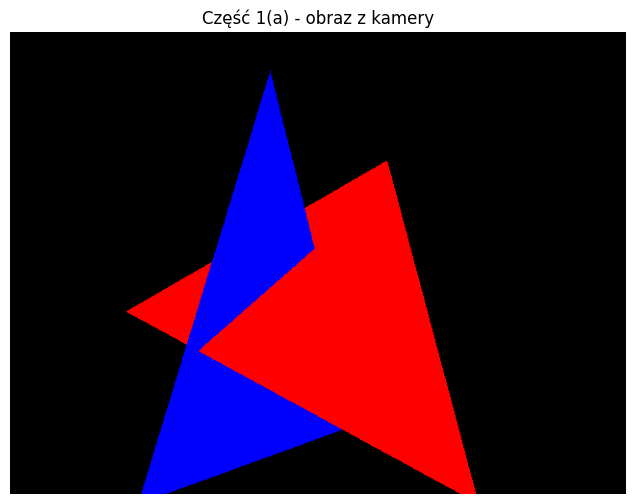

In [102]:
for index, triangle in enumerate(scene_1a, start=1):
    print(f"Trójkąt {index}: rzut na płaszczyznę obrazu OXY")
    print(np.round(project_points(triangle.vertices), 3))

frame_1a, _ = render_scene(scene_1a)
show_frame(frame_1a, "Część 1(a) - obraz z kamery")

## Część 1(b)

> Wariant (b) różni się od części 1(a) tylko tym, że z trójkąta A usuwam obszar wewnętrznego trójkąta. Sama projekcja, wybór koloru strony oraz z-bufor pozostają identyczne jak w części 1(a).

> Dziura jest definiowana przez wierzchołki `(0.8, 0.3, 10)`, `(-0.25, -0.25, 10.5)` oraz `(-0.25, 0.5, 9.5)`.

In [103]:
hole_1b = as_points((0.8, 0.3, 10.0), (-0.25, -0.25, 10.5), (-0.25, 0.5, 9.5))

triangle_a_1b = Triangle(
    vertices=triangle_a_1a.vertices,
    front_color=triangle_a_1a.front_color,
    back_color=triangle_a_1a.back_color,
    hole_vertices=None,
    )
triangle_a_1b.hole_vertices = hole_1b

scene_1b = [triangle_a_1b, triangle_b_1a]

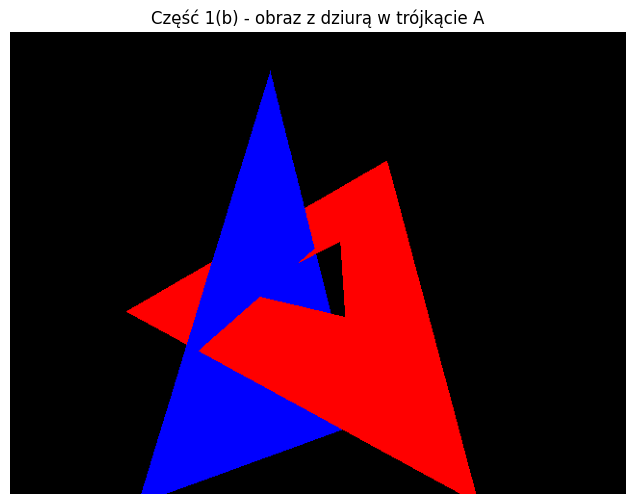

In [104]:
frame_1b, _ = render_scene(scene_1b)
show_frame(frame_1b, "Część 1(b) - obraz z dziurą w trójkącie A")

## Część 2(a)

> W tej części używam macierzy transformacji jednorodnej: najpierw obrót RPY, a potem przesunięcie. Kolory obu stron trójkątów pozostają takie same jak w części 1.

> Dla numeru albumu `223281` otrzymuję:
- trójkąt A: `roll = n · 2.8°`, `pitch = n · 1.1°`, przesunięcie `[0, 0.5, 10]`,
- trójkąt B: `roll = -n · 2.1°`, `pitch = -n · 1.8°`, przesunięcie `[0.5, 0, 10]`.

> Dodatkowo zapisuję krótką wersję animacji dla klatek od 36 do 45.

In [115]:
import base64
from typing import Any, Callable, cast

import imageio.v2 as imageio
from IPython.display import HTML, display
from matplotlib import pyplot as animation_plt


def show_frame_strip(samples: dict[int, np.ndarray], title: str) -> None:
    ordered = sorted(samples.items())
    fig, axes = animation_plt.subplots(1, len(ordered), figsize=(4.5 * len(ordered), 4.5))
    if len(ordered) == 1:
        axes = [axes]
    fig.suptitle(title)
    for ax, (frame_number, frame) in zip(axes, ordered):
        ax.imshow(frame)
        ax.set_title(f"Klatka {frame_number}")
        ax.axis("off")
    animation_plt.tight_layout()
    animation_plt.show()


def build_animation(
    triangles: list[Triangle],
    frame_numbers: range,
    transform_builder: Callable[[int], list[np.ndarray]],
    sample_numbers: tuple[int, ...] = (),
) -> tuple[bytes, dict[int, np.ndarray]]:
    frames: list[np.ndarray] = []
    samples: dict[int, np.ndarray] = {}
    sample_set = set(sample_numbers)
    for frame_number in frame_numbers:
        frame, _ = render_scene(triangles, transform_builder(frame_number))
        frames.append(frame)
        if frame_number in sample_set:
            samples[frame_number] = frame.copy()
    gif_bytes = cast(
        bytes,
        imageio.mimsave(
            cast(Any, "<bytes>"),
            cast(Any, frames),
            format=cast(Any, "GIF"),
            duration=0.05,
            loop=0,
        ),
    )
    return gif_bytes, samples


def display_gif(gif_bytes: bytes) -> None:
    gif_base64 = base64.b64encode(gif_bytes).decode("ascii")
    display(HTML(f'<img src="data:image/gif;base64,{gif_base64}" alt="Animacja trójkątów">'))

In [111]:
triangle_a_2a = Triangle(
    vertices=as_points((2.0, 0.0, 0.0), (-1.0, -2.0, 2.0), (-1.0, 1.0, -2.0)),
    front_color=(255, 0, 0),
    back_color=(0, 255, 0),
)
triangle_b_2a = Triangle(
    vertices=as_points((0.0, -2.0, 0.0), (-1.0, 2.0, 1.0), (1.0, 2.0, -1.0)),
    front_color=(0, 0, 255),
    back_color=(255, 255, 0),
)

scene_2a = [triangle_a_2a, triangle_b_2a]

roll_a_2a = 2.0 + a / 10.0
pitch_a_2a = 1.0 + b / 10.0
roll_b_2a = -(2.0 + b / 10.0)
pitch_b_2a = -(1.0 + a / 10.0)


def transforms_2a(frame_number: int) -> list[np.ndarray]:
    return [
        transform_matrix(
            roll_deg=frame_number * roll_a_2a,
            pitch_deg=frame_number * pitch_a_2a,
            translation=(0.0, 0.5, 10.0),
        ),
        transform_matrix(
            roll_deg=frame_number * roll_b_2a,
            pitch_deg=frame_number * pitch_b_2a,
            translation=(0.5, 0.0, 10.0),
        ),
    ]


print(f"Część 2(a): a = {a}, b = {b}")
print(f"Trójkąt A: roll = n * {roll_a_2a:.1f}°, pitch = n * {pitch_a_2a:.1f}°")
print(f"Trójkąt B: roll = n * {roll_b_2a:.1f}°, pitch = n * {pitch_b_2a:.1f}°")

Część 2(a): a = 8, b = 1
Trójkąt A: roll = n * 2.8°, pitch = n * 1.1°
Trójkąt B: roll = n * -2.1°, pitch = n * -1.8°



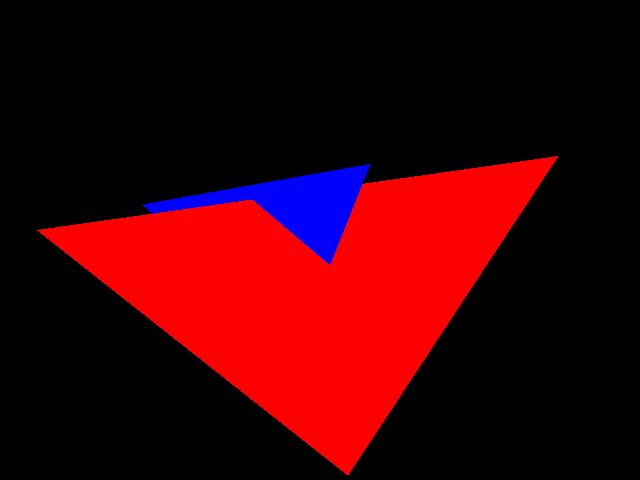


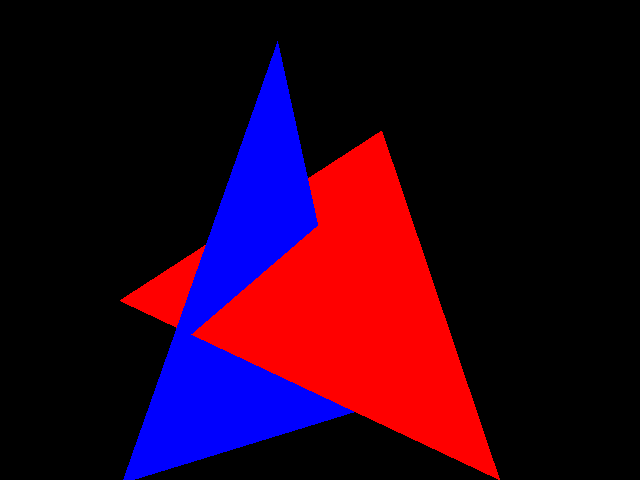

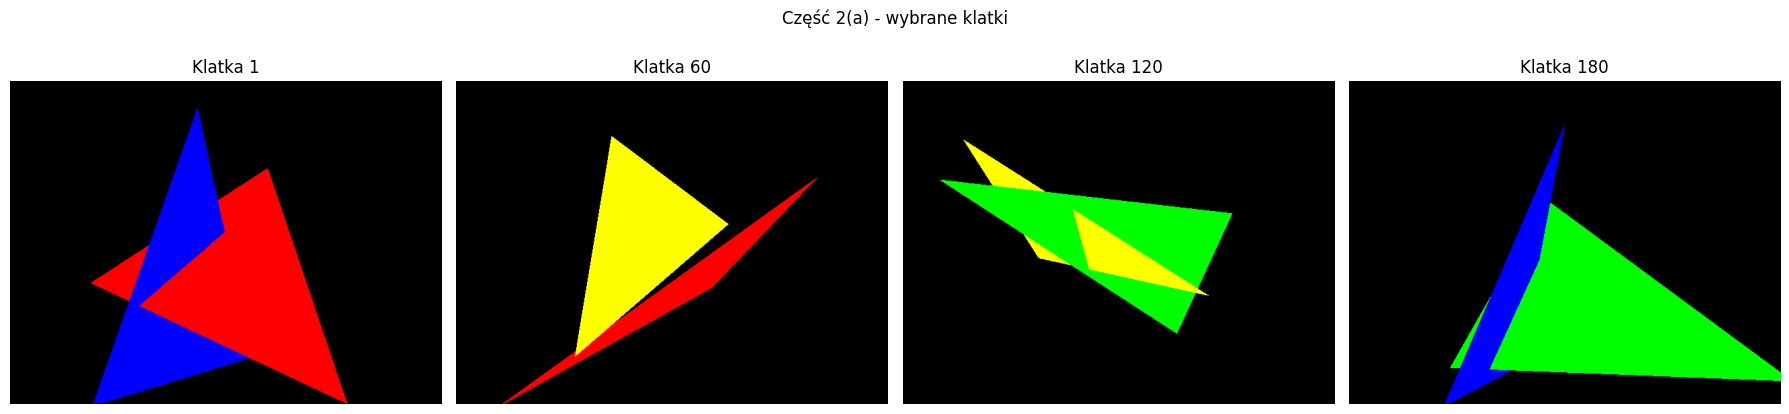

In [116]:
preview_gif_2a, _ = build_animation(scene_2a, range(36, 46), transforms_2a)
display_gif(preview_gif_2a)

full_gif_2a, samples_2a = build_animation(
    scene_2a,
    range(1, 181),
    transforms_2a,
    sample_numbers=(1, 60, 120, 180),
)
display_gif(full_gif_2a)
show_frame_strip(samples_2a, "Część 2(a) - wybrane klatki")

## Część 2(b)

> Wariant (b) zachowuje tę samą animację i tę samą konwencję macierzy co w części 2(a), ale w każdym kroku usuwam z trójkąta A obszar wewnętrznego trójkąta zdefiniowanego w położeniu początkowym.

> Oznacza to, że także dziura podlega temu samemu obrotowi i przesunięciu co zewnętrzny trójkąt A.

In [112]:
triangle_a_2b = Triangle(
    vertices=triangle_a_2a.vertices,
    front_color=triangle_a_2a.front_color,
    back_color=triangle_a_2a.back_color,
)
triangle_a_2b.hole_vertices = as_points((0.8, -0.2, 0.0), (-0.25, -0.75, 0.5), (-0.25, 0.0, -0.5))
triangle_b_2b = triangle_b_2a

scene_2b = [triangle_a_2b, triangle_b_2b]

roll_a_2b = 2.0 + a / 10.0
pitch_a_2b = 1.0 + b / 10.0
roll_b_2b = -(2.0 + b / 10.0)
pitch_b_2b = -(1.0 + a / 10.0)


def transforms_2b(frame_number: int) -> list[np.ndarray]:
    return [
        transform_matrix(
            roll_deg=frame_number * roll_a_2b,
            pitch_deg=frame_number * pitch_a_2b,
            translation=(0.0, 0.5, 10.0),
        ),
        transform_matrix(
            roll_deg=frame_number * roll_b_2b,
            pitch_deg=frame_number * pitch_b_2b,
            translation=(0.5, 0.0, 10.0),
        ),
    ]


print(f"Część 2(b): a = {a}, b = {b}")
print(f"Trójkąt A: roll = n * {roll_a_2b:.1f}°, pitch = n * {pitch_a_2b:.1f}°")
print(f"Trójkąt B: roll = n * {roll_b_2b:.1f}°, pitch = n * {pitch_b_2b:.1f}°")

Część 2(b): a = 8, b = 1
Trójkąt A: roll = n * 2.8°, pitch = n * 1.1°
Trójkąt B: roll = n * -2.1°, pitch = n * -1.8°



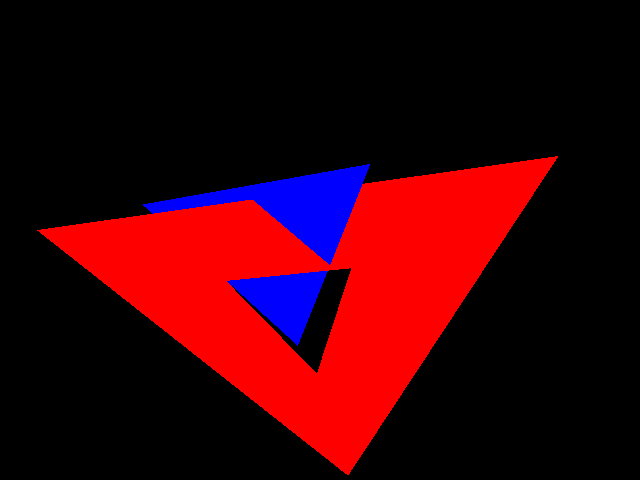


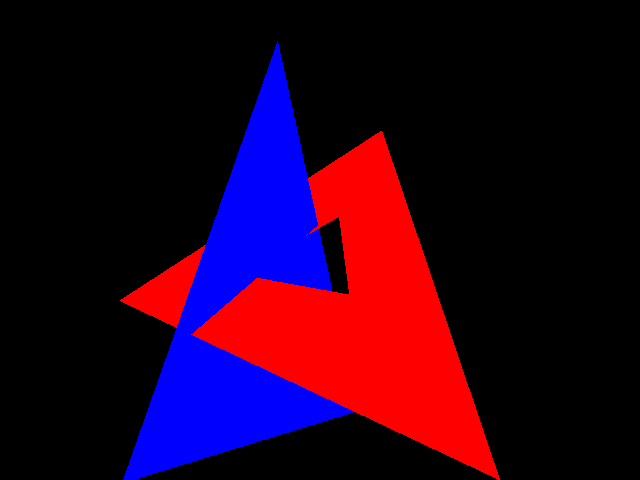

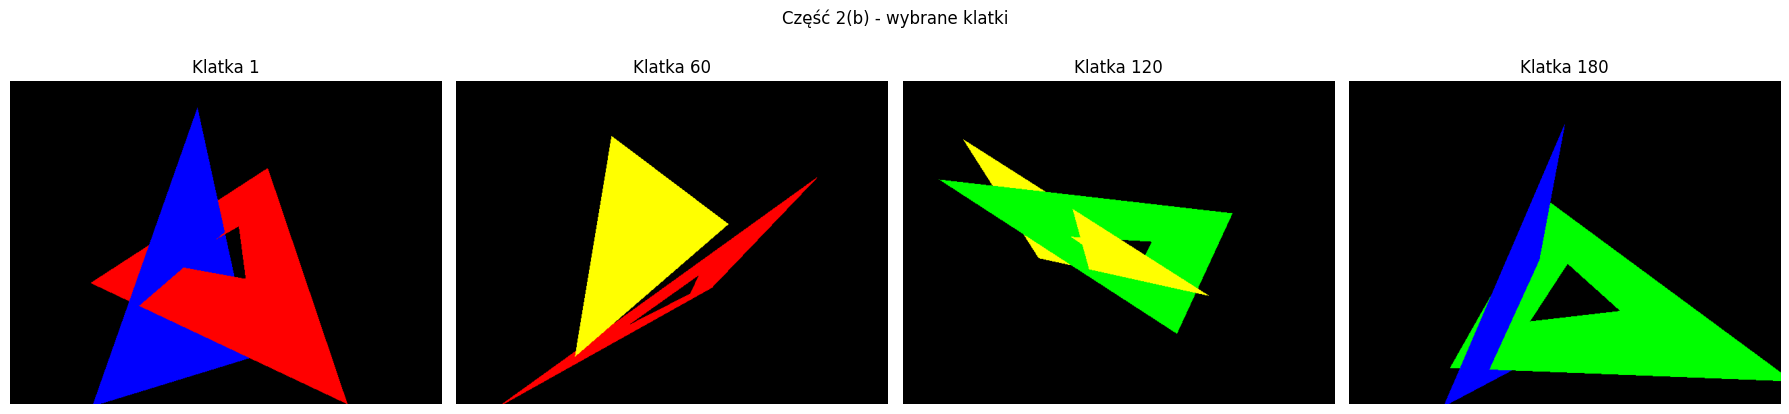

In [117]:
preview_gif_2b, _ = build_animation(scene_2b, range(36, 46), transforms_2b)
display_gif(preview_gif_2b)

full_gif_2b, samples_2b = build_animation(
    scene_2b,
    range(1, 181),
    transforms_2b,
    sample_numbers=(1, 60, 120, 180),
)
display_gif(full_gif_2b)
show_frame_strip(samples_2b, "Część 2(b) - wybrane klatki")